# 02 — Preprocessing Pipeline (Leakage-Free)

All `sklearn` `.fit()` calls use **train data only**.  
Test data is only **transformed** — never fitted.  
Outputs: 4 CSVs (train/test × scaled/unscaled) + 2 model artefacts.

In [1]:
import os, re, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.0)
plt.rcParams['figure.dpi'] = 120

SPLITS    = '../data/splits'
PROCESSED = '../data/processed'
MODELS    = '../models'
PLOTS     = '../results/plots'
for d in [SPLITS, PROCESSED, MODELS, PLOTS]:
    os.makedirs(d, exist_ok=True)
print('Dirs ready.')

c:\Users\Sreeansh Dash\OneDrive\Desktop\Projects\Machine_Learning_Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dirs ready.


## Step 1 — Load Raw Data & Split by Patient IDs

In [2]:
print('Loading NidaanKosha...')
ds = load_dataset('ekacare/NidaanKosha-100k-V1.0')
df = ds['train'].to_pandas()
print(f'Raw shape: {df.shape}')

train_ids = pd.read_csv(f'{SPLITS}/train_ids.csv')['document_id'].tolist()
test_ids  = pd.read_csv(f'{SPLITS}/test_ids.csv')['document_id'].tolist()
print(f'Train patients: {len(train_ids):,}  |  Test patients: {len(test_ids):,}')

df_train = df[df['document_id'].isin(train_ids)].copy()
df_test  = df[df['document_id'].isin(test_ids)].copy()
print(f'df_train rows: {len(df_train):,}  |  df_test rows: {len(df_test):,}')

Loading NidaanKosha...


Raw shape: (6844304, 9)
Train patients: 80,000  |  Test patients: 20,000
df_train rows: 5,471,090  |  df_test rows: 1,373,214


## Step 2 — Specimen Filter (Blood Only)

In [3]:
BLOOD_TYPES = {'blood', 'serum', 'plasma', 'whole blood'}

def filter_blood(df):
    mask = df['specimen'].str.lower().str.strip().isin(BLOOD_TYPES)
    return df[mask].copy()

print('Before filter:')
print(df_train['specimen'].value_counts().head(10).to_string())

df_train = filter_blood(df_train)
df_test  = filter_blood(df_test)
print(f'\nAfter filter — train: {len(df_train):,}  test: {len(df_test):,}')

Before filter:
specimen
blood          4347611
urine           796686
stool             3822
pus                781
body_fluid         593
respiratory        495
patient            388
semen              346
tissue              74
urine_24h           45

After filter — train: 4,347,611  test: 1,088,964


## Step 3 — LOINC-Based Column Standardisation

- Group rows by LOINC code; assign **canonical test name** = most common `test_name` for that LOINC in **train**.
- Rows with no LOINC: keep `test_name` as-is.
- Apply mapping to both splits.

In [4]:
# Build mapping on TRAIN only
loinc_map = (
    df_train.dropna(subset=['loinc'])
            .groupby('loinc')['test_name']
            .agg(lambda x: x.value_counts().index[0])  # modal test_name
)
print(f'LOINC codes mapped: {len(loinc_map)}')
print(loinc_map.head(10).to_string())

def apply_loinc_map(df, mapping):
    df = df.copy()
    df['canonical_test'] = df.apply(
        lambda r: mapping.get(r['loinc'], r['test_name']) if pd.notna(r['loinc']) else r['test_name'],
        axis=1
    )
    return df

df_train = apply_loinc_map(df_train, loinc_map)
df_test  = apply_loinc_map(df_test,  loinc_map)
print(f'\nUnique canonical tests — train: {df_train["canonical_test"].nunique()}')

LOINC codes mapped: 372
loinc
101206-1            DENGUE FEVER ANTIGEN NS1 EIA
10331-7                                Rh TYPING
10334-1     CA 125; OVARIAN CANCER MARKER, SERUM
10378-8                            Polychromasia
10501-5                                       LH
10710-2                               THIN SMEAR
10835-7                            Lipoprotein a
10886-0     Free-PSA (Prostate Specific Antigen)
11039-5         C-Reactive Protein (Qualitative)
11054-4                          LDL / HDL RATIO

Unique canonical tests — train: 9447


In [5]:
# Keep only tests present in >= 20% of TRAIN patients
n_train_pts = df_train['document_id'].nunique()
cov = df_train.groupby('canonical_test')['document_id'].nunique()
cov_pct = cov / n_train_pts
selected_tests = cov_pct[cov_pct >= 0.20].index.tolist()
print(f'Tests with >=20% patient coverage: {len(selected_tests)}')

df_train = df_train[df_train['canonical_test'].isin(selected_tests)].copy()
df_test  = df_test[df_test['canonical_test'].isin(selected_tests)].copy()
print(f'Train rows after test selection: {len(df_train):,}')
print(f'Test  rows after test selection: {len(df_test):,}')

Tests with >=20% patient coverage: 68
Train rows after test selection: 3,877,710
Test  rows after test selection: 970,608


## Step 4 — Unit Normalisation (LOINC-Aware)

For each canonical test, the **modal unit in training** is determined.  
Known conversion factors are applied when a row uses a non-modal unit.
**No value-threshold heuristics** — only actual unit string matching.

In [6]:
# Known unit conversions: (from_unit, to_unit) -> multiply_factor
UNIT_CONV = {
    # Haematology — cell counts
    ('/µL',     '10^3/µL'): 1e-3,
    ('/ul',     '10^3/µL'): 1e-3,
    ('cells/µL','10^3/µL'): 1e-3,
    ('10^6/µL', '10^3/µL'): 1e3,
    ('10^9/L',  '10^3/µL'): 1.0,
    ('/mm3',    '10^3/µL'): 1e-3,
    ('x10^3/µL','10^3/µL'): 1.0,
    ('K/µL',    '10^3/µL'): 1.0,
    # Haemoglobin
    ('g/l',     'g/dL'): 0.1,
    ('g/L',     'g/dL'): 0.1,
    # Glucose / HbA1c
    ('mmol/L',  'mg/dL'): 18.016,  # glucose
    ('mg/dl',   'mg/dL'): 1.0,
    # Lipids — cholesterol
    ('mmol/l',  'mg/dL'): 38.67,
    # Creatinine
    ('µmol/L',  'mg/dL'): 0.01131,
    ('umol/L',  'mg/dL'): 0.01131,
    # Thyroid (TSH)
    ('mU/L',    'mIU/L'): 1.0,
    ('µU/mL',   'mIU/L'): 1.0,
    ('uIU/mL',  'mIU/L'): 1.0,
    # Liver enzymes
    ('IU/L',    'U/L'): 1.0,
    ('u/l',     'U/L'): 1.0,
    # Iron
    ('µg/dL',   'μg/dL'): 1.0,
    ('ug/dL',   'μg/dL'): 1.0,
}

# Fit modal units on TRAIN only
modal_unit = (
    df_train.dropna(subset=['unit'])
            .groupby('canonical_test')['unit']
            .agg(lambda x: x.value_counts().index[0])
)
print(f'Modal units determined for {len(modal_unit)} tests')

def normalise_units(df, modal_unit_map, conv_table):
    df = df.copy()
    df['value'] = pd.to_numeric(df['value'], errors='coerce')
    for test, modal in modal_unit_map.items():
        mask = (df['canonical_test'] == test) & (df['unit'] != modal) & df['unit'].notna()
        for row_idx in df[mask].index:
            from_u = df.at[row_idx, 'unit']
            factor = conv_table.get((from_u, modal), None)
            if factor is not None:
                df.at[row_idx, 'value'] = df.at[row_idx, 'value'] * factor
                df.at[row_idx, 'unit']  = modal
    return df

print('Normalising train units...')
df_train = normalise_units(df_train, modal_unit, UNIT_CONV)
print('Normalising test  units...')
df_test  = normalise_units(df_test,  modal_unit, UNIT_CONV)
print('Unit normalisation done.')

Modal units determined for 68 tests
Normalising train units...
Normalising test  units...
Unit normalisation done.


## Step 5 — Long → Wide Pivot

In [7]:
def long_to_wide(df):
    df = df.copy()
    df['value'] = pd.to_numeric(df['value'], errors='coerce')
    wide = df.pivot_table(
        index='document_id',
        columns='canonical_test',
        values='value',
        aggfunc='median'  # median across duplicate tests per patient
    )
    wide.columns.name = None
    wide = wide.reset_index()
    # Merge demographics
    demo = df[['document_id','age','gender']].drop_duplicates('document_id')
    demo['age'] = pd.to_numeric(demo['age'], errors='coerce')
    wide = wide.merge(demo, on='document_id', how='left')
    return wide

print('Pivoting train...')
train_wide = long_to_wide(df_train)
print('Pivoting test...')
test_wide  = long_to_wide(df_test)

# Align columns: test set must have SAME columns as train
feat_cols = [c for c in train_wide.columns if c not in ['document_id','age','gender']]
for col in feat_cols:
    if col not in test_wide.columns:
        test_wide[col] = np.nan
test_wide = test_wide[train_wide.columns]  # same column order

print(f'Train wide: {train_wide.shape}  |  Test wide: {test_wide.shape}')

Pivoting train...
Pivoting test...
Train wide: (79993, 71)  |  Test wide: (19999, 71)


## Step 6 — Missing Value Handling

- Add binary missingness indicators for features with >20% missing **in train**.
- Fit `SimpleImputer(median)` on **train** only.

In [8]:
# Compute missingness rate on TRAIN
miss_rate_train = train_wide[feat_cols].isnull().mean()
high_miss = miss_rate_train[miss_rate_train > 0.20].index.tolist()
print(f'Features with >20% missing in train: {len(high_miss)}')

# Add binary missingness indicators (apply to both splits)
for col in high_miss:
    train_wide[col + '_missing'] = train_wide[col].isnull().astype(int)
    test_wide[col  + '_missing'] = test_wide[col].isnull().astype(int)

# Recompute feat_cols to include missingness indicators
miss_indicator_cols = [c + '_missing' for c in high_miss]
num_cols = feat_cols  # original numeric features

# Fit imputer on TRAIN
imputer = SimpleImputer(strategy='median')
train_wide[num_cols] = imputer.fit_transform(train_wide[num_cols])
test_wide[num_cols]  = imputer.transform(test_wide[num_cols])

joblib.dump(imputer, f'{MODELS}/imputer.pkl')
print('Imputer saved → models/imputer.pkl')
print(f'Missing after imputation — train: {train_wide[num_cols].isnull().sum().sum()}')
print(f'Missing after imputation — test : {test_wide[num_cols].isnull().sum().sum()}')

Features with >20% missing in train: 38
Imputer saved → models/imputer.pkl
Missing after imputation — train: 0
Missing after imputation — test : 0


## Step 7 — Outlier Handling (Medical-Safe)

Cap at ±5 standard deviations from the **training mean** only.  
5σ is chosen because extreme lab values are often real disease signals, not noise.

In [9]:
train_means = train_wide[num_cols].mean()
train_stds  = train_wide[num_cols].std()

lo = train_means - 5 * train_stds
hi = train_means + 5 * train_stds

def cap_outliers(df, lo, hi, cols):
    df = df.copy()
    for col in cols:
        df[col] = df[col].clip(lower=lo[col], upper=hi[col])
    return df

train_wide = cap_outliers(train_wide, lo, hi, num_cols)
test_wide  = cap_outliers(test_wide,  lo, hi, num_cols)
print('Outlier capping done (5σ from train mean).')

# Save UNSCALED wide format (needed for clinical threshold labeling in 04)
train_wide.to_csv(f'{PROCESSED}/train_wide_unscaled.csv', index=False)
test_wide.to_csv( f'{PROCESSED}/test_wide_unscaled.csv',  index=False)
print('Unscaled CSVs saved.')

Outlier capping done (5σ from train mean).
Unscaled CSVs saved.


## Step 8 — Standard Scaling

Fit `StandardScaler` on **train** (numeric test columns only — exclude `age` and missingness indicators).  
Transform both splits.

In [10]:
scale_cols = num_cols  # age is in demo, not in feat_cols; missingness indicators stay binary

scaler = StandardScaler()
train_scaled = train_wide.copy()
test_scaled  = test_wide.copy()

train_scaled[scale_cols] = scaler.fit_transform(train_wide[scale_cols])
test_scaled[scale_cols]  = scaler.transform(test_wide[scale_cols])

joblib.dump(scaler, f'{MODELS}/scaler.pkl')
print('Scaler saved → models/scaler.pkl')

Scaler saved → models/scaler.pkl


## Step 9 — Save All Outputs

In [11]:
train_scaled.to_csv(f'{PROCESSED}/train_wide_scaled.csv', index=False)
test_scaled.to_csv( f'{PROCESSED}/test_wide_scaled.csv',  index=False)
print('Scaled CSVs saved.')

print('\n=== PREPROCESSING SUMMARY ===')
print(f'Train shape (scaled): {train_scaled.shape}')
print(f'Test  shape (scaled): {test_scaled.shape}')
print(f'Numeric features     : {len(num_cols)}')
print(f'Missingness indicators: {len(miss_indicator_cols)}')
print(f'Missing % before imputation (train mean): {miss_rate_train.mean()*100:.1f}%')
print(f'Missing % after  imputation (train)     : {train_wide[num_cols].isnull().mean().mean()*100:.1f}%')
print('\nFiles saved:')
print('  data/processed/train_wide_scaled.csv')
print('  data/processed/test_wide_scaled.csv')
print('  data/processed/train_wide_unscaled.csv')
print('  data/processed/test_wide_unscaled.csv')
print('  models/imputer.pkl')
print('  models/scaler.pkl')

Scaled CSVs saved.

=== PREPROCESSING SUMMARY ===
Train shape (scaled): (79993, 109)
Test  shape (scaled): (19999, 109)
Numeric features     : 68
Missingness indicators: 38
Missing % before imputation (train mean): 29.0%
Missing % after  imputation (train)     : 0.0%

Files saved:
  data/processed/train_wide_scaled.csv
  data/processed/test_wide_scaled.csv
  data/processed/train_wide_unscaled.csv
  data/processed/test_wide_unscaled.csv
  models/imputer.pkl
  models/scaler.pkl


## Appendix — Missingness Heatmap (Sample)

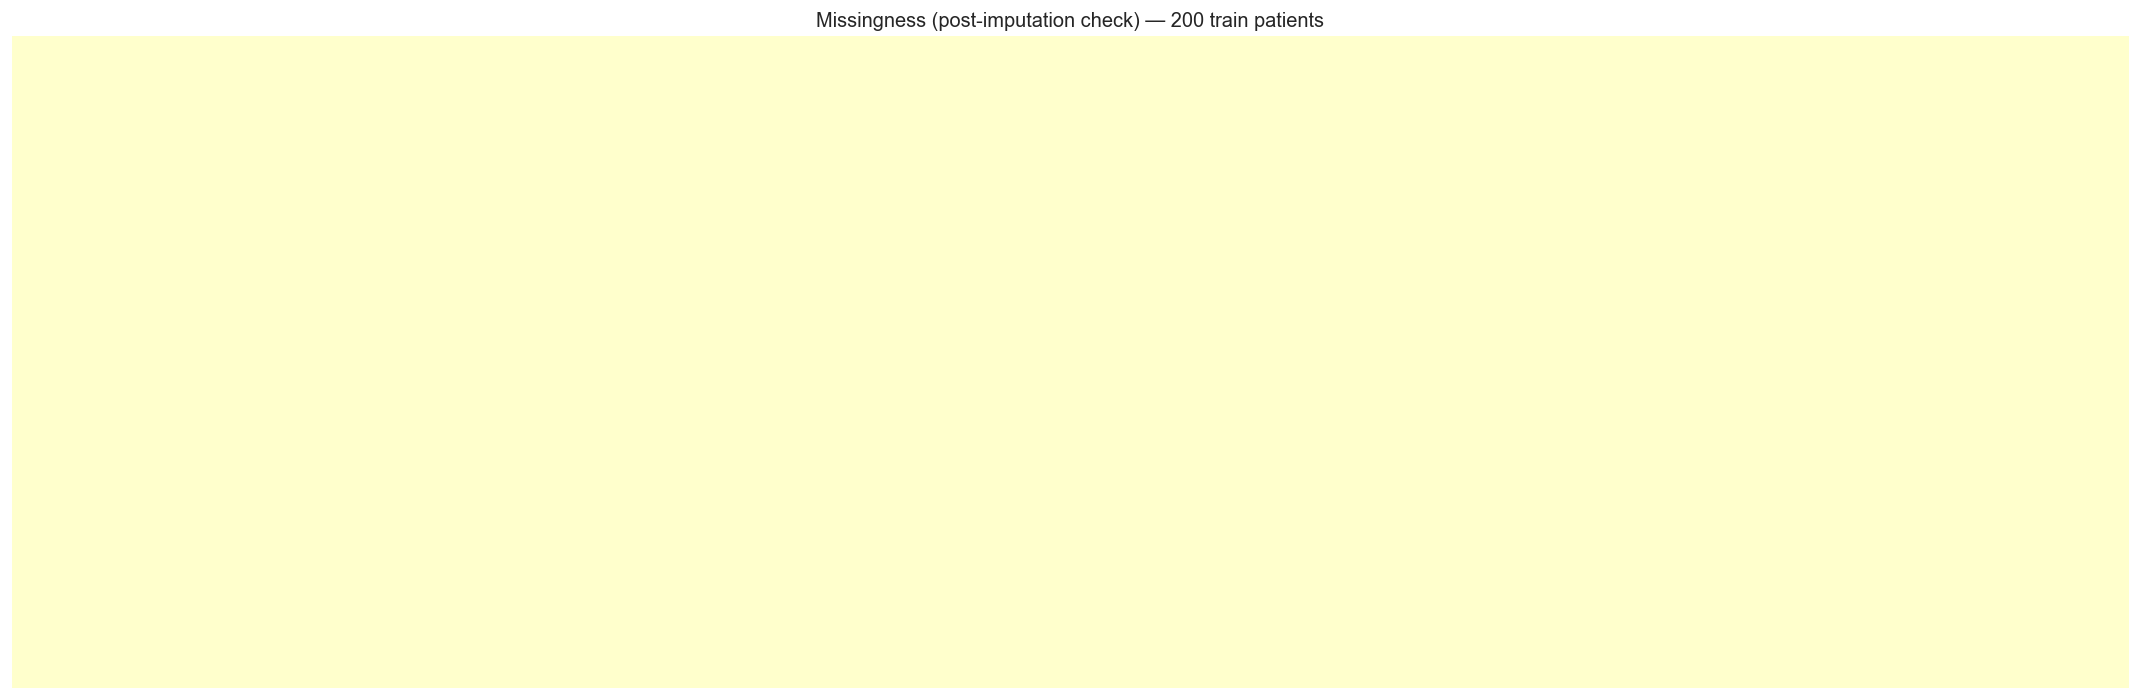

In [12]:
# Visualise missingness on a 200-patient sample of train
sample_ids = train_wide.sample(200, random_state=42)['document_id']
sample_df  = train_wide[train_wide['document_id'].isin(sample_ids)][num_cols]

# Before imputation we'd need the raw — we show the post-imputation heatmap of scaled values
fig, ax = plt.subplots(figsize=(18, 6))
sns.heatmap(sample_df.isnull(), cmap='YlOrRd', cbar=False,
            xticklabels=False, yticklabels=False, ax=ax)
ax.set_title('Missingness (post-imputation check) — 200 train patients')
plt.tight_layout()
plt.savefig(f'{PLOTS}/imputation_heatmap.png', bbox_inches='tight')
plt.show()